
# A Data Science Approach to Operational Efficiency & No-show Prediction For `Goodlife Fitness`

Presented By **`Group 3:`**
                    
 ###               ***`Thompson, Tavleen & Sachin`*** 

###  Load and Explore the Datasets

Problem 1 Dataset:
   number_people                       date  timestamp  day_of_week  \
0             37  2015-08-14 17:00:11-07:00      61211            4   
1             45  2015-08-14 17:20:14-07:00      62414            4   
2             40  2015-08-14 17:30:15-07:00      63015            4   
3             44  2015-08-14 17:40:16-07:00      63616            4   
4             45  2015-08-14 17:50:17-07:00      64217            4   

   is_weekend  is_holiday  temperature  is_start_of_semester  \
0           0           0        71.76                     0   
1           0           0        71.76                     0   
2           0           0        71.76                     0   
3           0           0        71.76                     0   
4           0           0        71.76                     0   

   is_during_semester  month  hour  
0                   0      8    17  
1                   0      8    17  
2                   0      8    17  
3                   0

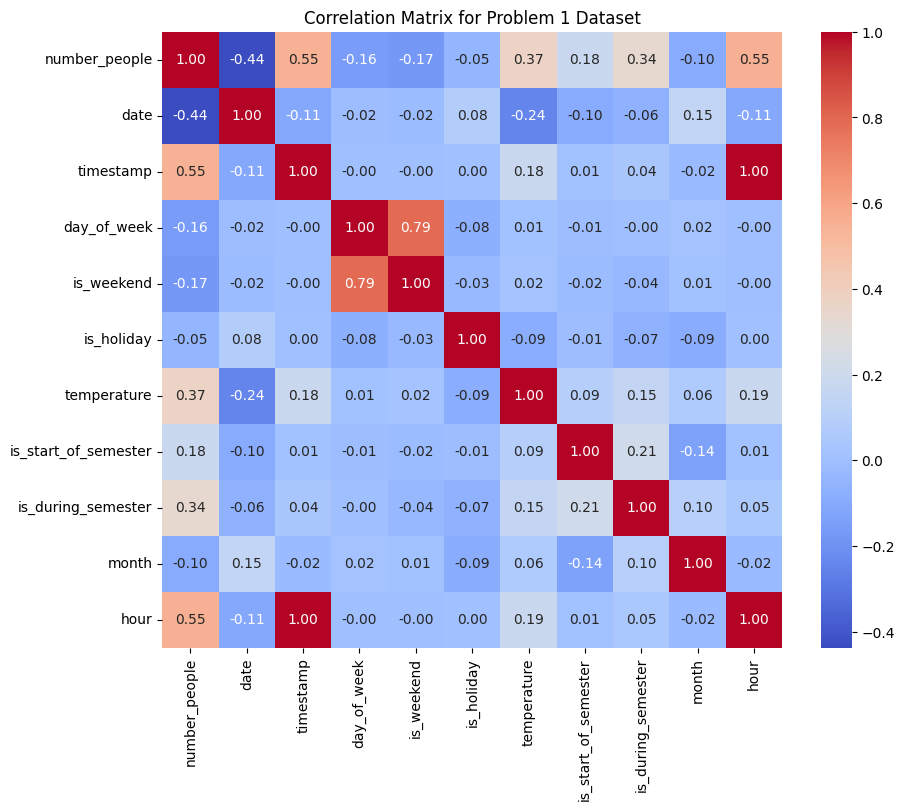

c:\Users\DELL\Desktop\Class\venv\CSCN8010_classic_ml\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


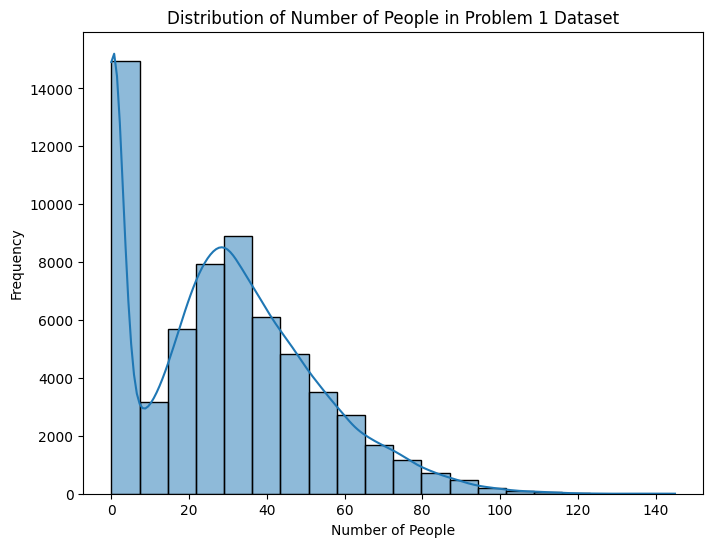

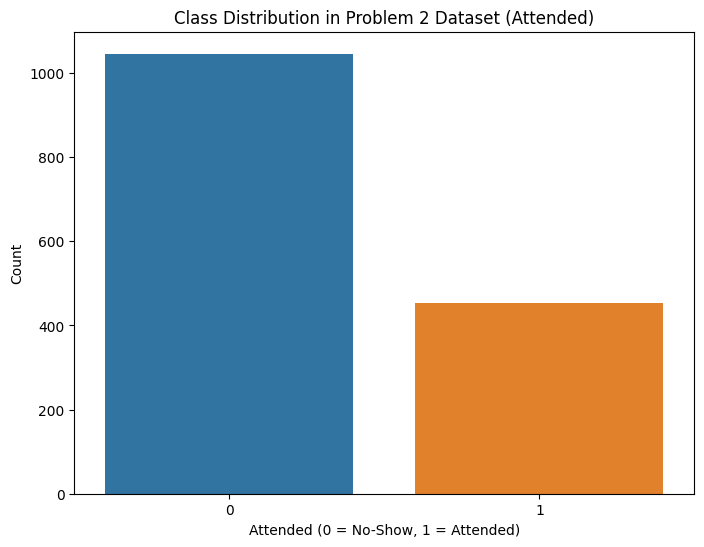

X_train shape: (43528, 10), y_train shape: (43528,)
X_test shape: (18656, 10), y_test shape: (18656,)


In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the datasets
problem1_df = pd.read_csv('problem1.csv')
problem2_df = pd.read_csv('problem2.csv')

# Display the first few rows of each dataset
print("Problem 1 Dataset:")
print(problem1_df.head())

print("\nProblem 2 Dataset:")
print(problem2_df.head())

# Handling missing values (if any)

# Fill numeric columns with the mean
problem1_df.fillna(problem1_df.select_dtypes(include='number').mean(), inplace=True)
problem2_df.fillna(problem2_df.select_dtypes(include='number').mean(), inplace=True)

# Fill non-numeric columns with a placeholder or mode
for column in problem1_df.select_dtypes(include='object').columns:
    problem1_df[column] = problem1_df[column].fillna('Unknown')  # Or use problem1_df[column] = problem1_df[column].fillna(problem1_df[column].mode()[0])

for column in problem2_df.select_dtypes(include='object').columns:
    problem2_df[column] = problem2_df[column].fillna('Unknown')  # Or use problem2_df[column] = problem2_df[column].fillna(problem2_df[column].mode()[0])

# Encoding categorical variables
label_encoder = LabelEncoder()

# Apply label encoding to categorical columns in problem1_df
for column in problem1_df.select_dtypes(include=['object']).columns:
    problem1_df[column] = label_encoder.fit_transform(problem1_df[column])

# Apply label encoding to categorical columns in problem2_df
for column in problem2_df.select_dtypes(include=['object']).columns:
    problem2_df[column] = label_encoder.fit_transform(problem2_df[column])

# Data Exploration

# Correlation matrix for Problem 1 Dataset
plt.figure(figsize=(10, 8))
sns.heatmap(problem1_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix for Problem 1 Dataset')
plt.show()

# Distribution of the target variable in Problem 1 Dataset (number_people)
plt.figure(figsize=(8, 6))
sns.histplot(problem1_df['number_people'], bins=20, kde=True)
plt.title('Distribution of Number of People in Problem 1 Dataset')
plt.xlabel('Number of People')
plt.ylabel('Frequency')
plt.show()

# Class distribution in Problem 2 Dataset (attended)
plt.figure(figsize=(8, 6))
sns.countplot(x='attended', data=problem2_df)
plt.title('Class Distribution in Problem 2 Dataset (Attended)')
plt.xlabel('Attended (0 = No-Show, 1 = Attended)')
plt.ylabel('Count')
plt.show()

# Train-test split for Problem 1 Dataset
target_column = 'number_people'  # Replace with the actual column name

# Separating features and target
features = problem1_df.drop(target_column, axis=1)
target = problem1_df[target_column]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# Standardizing the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Output the shapes of the train and test sets to verify
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


### 2. Modeling

### Predicting the Number of People at the Facility

For the first dataset, the target variable is number_people, and we can treat this as a regression problem. Let's use a Random Forest Regressor to predict the number of people based on the features provide

In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Instantiate the model
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_regressor.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_regressor.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor - Number of People Prediction")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")


Random Forest Regressor - Number of People Prediction
Mean Squared Error: 28.803609975343058
R-squared: 0.9441181451867349


Deductions:

    R-squared (R²): An R² value of 0.9441 indicates that approximately 94.41% of the variance in the number of people at the facility can be explained by the features used in the model. This suggests that the model has a strong ability to predict the number of people based on the given inputs (e.g., day of the week, temperature, hour of the day, etc.).
    Mean Squared Error (MSE): The MSE of 28.80 represents the average squared difference between the actual and predicted number of people. While this number gives a sense of the magnitude of errors, it’s more meaningful when compared with the scale of the target variable. Given the high R² value, the MSE indicates that the predictions are reasonably close to the actual values.

Conclusion:

    The model is performing well, with a high degree of accuracy in predicting the number of people at the facility. This indicates that the features used (such as day of the week, time, temperature, etc.) are highly predictive of the number of attendees, making this model useful for operational planning and resource allocation.

###  Predicting Attendance (No-Show) for Bookings

For the second dataset, the target variable is attended, where 0 indicates a no-show and 1 indicates attendance. This is a classification problem, and we can use a Random Forest Classifier to predict the likelihood of attendance

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier  # Ensure this is imported
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Load the datasets
problem2_df = pd.read_csv('problem2.csv')

# Display the first few rows of the dataset
print("Problem 2 Dataset:")
print(problem2_df.head())

# Handling missing values (if any)
problem2_df.fillna(problem2_df.select_dtypes(include='number').mean(), inplace=True)

# Fill non-numeric columns with a placeholder or mode
for column in problem2_df.select_dtypes(include='object').columns:
    problem2_df[column] = problem2_df[column].fillna('Unknown')  # Or use problem2_df[column] = problem2_df[column].fillna(problem2_df[column].mode()[0])

# Encoding categorical variables
label_encoder = LabelEncoder()

# Prepare the data for Problem 2 Dataset (No-Show Prediction)
# Separate features and target
features_no_show = problem2_df.drop('attended', axis=1)
target_no_show = problem2_df['attended']

# Encode any remaining categorical variables
for column in features_no_show.select_dtypes(include=['object']).columns:
    features_no_show[column] = label_encoder.fit_transform(features_no_show[column])

# Train-test split
X_train_no_show, X_test_no_show, y_train_no_show, y_test_no_show = train_test_split(features_no_show, target_no_show, test_size=0.3, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_no_show = scaler.fit_transform(X_train_no_show)
X_test_no_show = scaler.transform(X_test_no_show)

# Instantiate the model
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train_no_show, y_train_no_show)

# Make predictions
y_pred_rf_no_show = rf_classifier.predict(X_test_no_show)

# Evaluate the model
print("Random Forest Classifier - No-Show Prediction")
print(confusion_matrix(y_test_no_show, y_pred_rf_no_show))
print(classification_report(y_test_no_show, y_pred_rf_no_show))

# Calculate ROC AUC Score
roc_auc = roc_auc_score(y_test_no_show, rf_classifier.predict_proba(X_test_no_show)[:, 1])
print(f"ROC AUC Score: {roc_auc}")


Problem 2 Dataset:
   booking_id  months_as_member  weight days_before day_of_week time  \
0           1                17   79.56           8         Wed   PM   
1           2                10   79.01           2         Mon   AM   
2           3                16   74.53          14         Sun   AM   
3           4                 5   86.12          10         Fri   AM   
4           5                15   69.29           8         Thu   AM   

   category  attended  
0  Strength         0  
1      HIIT         0  
2  Strength         0  
3   Cycling         0  
4      HIIT         0  
Random Forest Classifier - No-Show Prediction
[[264  29]
 [ 87  70]]
              precision    recall  f1-score   support

           0       0.75      0.90      0.82       293
           1       0.71      0.45      0.55       157

    accuracy                           0.74       450
   macro avg       0.73      0.67      0.68       450
weighted avg       0.74      0.74      0.72       450

ROC AUC 

Deductions:

    Confusion Matrix: The model correctly identifies no-shows (class 0) 264 times (True Negatives) and falsely predicts 29 bookings as no-shows when they were attended (False Positives). It correctly identifies attended bookings (class 1) 70 times (True Positives) but fails to identify 87 attended bookings (False Negatives).
    Precision and Recall:
        For No-Shows (Class 0): The model has a high recall (0.90), meaning it effectively identifies most no-shows, which is important for operational efficiency. Precision (0.75) indicates that when the model predicts a no-show, it is correct 75% of the time.
        For Attended (Class 1): The model's recall for attended bookings is lower (0.45), meaning it misses a significant number of attended bookings, which could be problematic if the goal is to avoid overbooking. Precision for attended bookings is 0.71, meaning that when it predicts attendance, it is correct 71% of the time.
    F1-Score: The F1-score for no-shows (0.82) indicates a good balance between precision and recall, while the F1-score for attended bookings (0.55) suggests room for improvement in capturing true attended bookings.
    ROC AUC Score: An AUC of 0.792 suggests that the model has a reasonable ability to discriminate between no-shows and attended bookings. It indicates that there is a 79.2% chance that the model will correctly distinguish between a randomly chosen no-show and a randomly chosen attended booking.

Conclusion:

    Strengths: The model performs well in predicting no-shows, which is crucial for reducing resource wastage and optimizing scheduling.
    Weaknesses: The lower recall and F1-score for attended bookings indicate that the model struggles to accurately predict when a booking will be attended, which could lead to challenges in managing bookings and ensuring adequate resource allocation.
    Overall: The model is useful for predicting no-shows but may require further tuning or additional features to improve its ability to predict attended bookings accurately. This could involve balancing the dataset or adjusting model hyperparameters to reduce the number of false negatives (missed attended bookings).

Business Implications:

    Operational Efficiency:
        The accurate prediction of the number of people at the facility enables GoodLife Fitness to allocate resources efficiently, ensuring that staff and equipment are available as needed without over- or under-preparation.

    Customer Satisfaction:
        By effectively predicting no-shows, the facility can reduce the impact of missed bookings on its operations, potentially filling those slots with other customers or adjusting staffing accordingly. However, improving the model's ability to predict actual attendance is crucial for minimizing customer dissatisfaction due to overbooking or resource unavailability.

    Model Improvement:
        To enhance the model's performance, particularly in predicting attended bookings, GoodLife Fitness could consider feature engineering, adding new data points (e.g., customer behavior patterns), or exploring other classification algorithms. Additionally, balancing the dataset to address class imbalance might improve the model's ability to predict attended bookings accurately.